In [1]:
import matplotlib.pyplot as plt
import numpy as np
import lab1package as lab
import pandas as pd
from scipy.stats import kurtosis, skew
import os

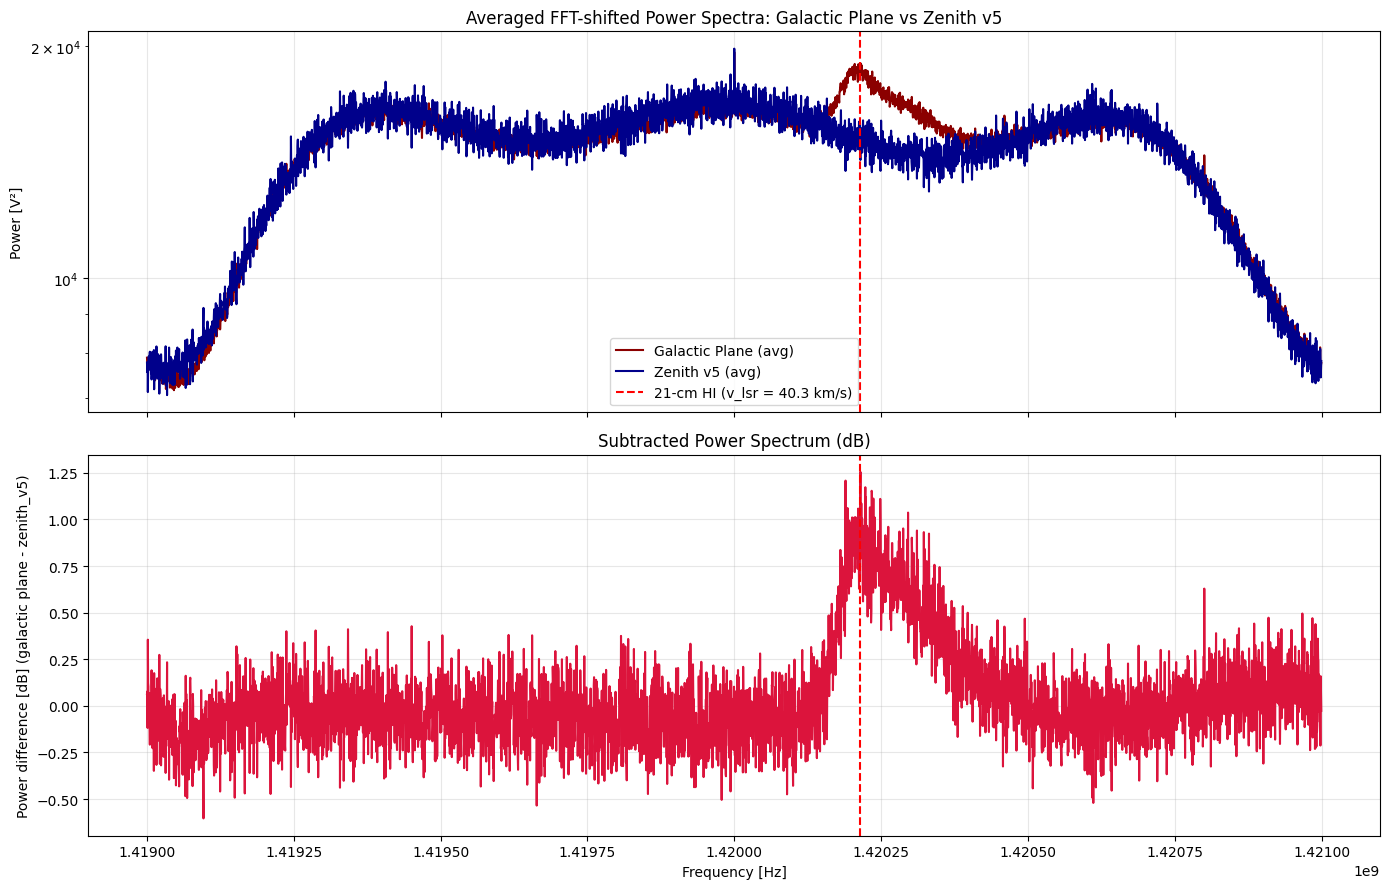

Max dB difference: 1.254 dB at 1.420e+09 Hz
Min dB difference: -0.604 dB at 1.419e+09 Hz
HI line frequency (adjusted): 1.420215e+09 Hz
Doppler shift: 40.32 km/s
Saved figure: Lab 2/figures/galactic_plane_minus_zenith_v5_difference.png


In [2]:
# Subtracted averaged fftshifted power spectrum: galactic plane - zenith v5
# Loads `bighorn_galactic_plane.npz` and `bighorn_zenith_v5.npz`, averages fftshifted power per block, subtracts and plots
# Includes Doppler shift for HI line based on velocity

# === Doppler/redshift parameters ===
f_HI_rest = 1420.40575177e6  # Rest frequency of 21 cm HI line [Hz]
c = 3e8  # Speed of light [m/s]
v_lsr = 40.32  # Line-of-sight velocity relative to LSR [km/s]. Positive = receding, Negative = approaching

# Convert velocity to frequency shift (Doppler formula, non-relativistic approximation valid for v << c)
# For small velocities: Δf/f ≈ -v/c (negative because receding increases wavelength)
f_HI = f_HI_rest * (1.0 - v_lsr * 1000 / c)  # Convert km/s to m/s

fn_gal = "bighorn_galactic_plane.npz"
fn_zen_v5 = "bighorn_zenith_v5.npz"

data_gal = np.load(fn_gal)
data_zen_v5 = np.load(fn_zen_v5)

samples_gal = data_gal["samples"]
samples_zen_v5 = data_zen_v5["samples"]

fs_local = 2e6
f_offset = 1420e6

# helper to compute averaged fftshifted power
def avg_shifted_power(samples_arr, fs):
    num_blocks = samples_arr.shape[0]
    N = samples_arr.shape[1]
    acc = np.zeros(N, dtype=float)
    for i in range(num_blocks):
        blk = samples_arr[i]
        x_blk = blk[:,0] + 1j*blk[:,1]
        X_blk = np.fft.fft(x_blk)
        Xs = np.fft.fftshift(X_blk)
        P = (np.abs(Xs)**2) / N
        acc += P
    Pavg = acc / num_blocks
    freqs = np.fft.fftfreq(N, 1/fs)
    freqs_shift = np.fft.fftshift(freqs) + f_offset
    return freqs_shift, Pavg

freq_gal, Pgal = avg_shifted_power(samples_gal, fs_local)
freq_zen_v5, Pzen_v5 = avg_shifted_power(samples_zen_v5, fs_local)

# align frequency axes if needed
if len(freq_gal) != len(freq_zen_v5) or not np.allclose(freq_gal, freq_zen_v5):
    fmin = max(freq_gal.min(), freq_zen_v5.min())
    fmax = min(freq_gal.max(), freq_zen_v5.max())
    npts = min(len(freq_gal), len(freq_zen_v5))
    f_common = np.linspace(fmin, fmax, npts)
    Pgal_i = np.interp(f_common, freq_gal, Pgal)
    Pzen_v5_i = np.interp(f_common, freq_zen_v5, Pzen_v5)
    f_plot = f_common
    Pgal_plot = Pgal_i
    Pzen_v5_plot = Pzen_v5_i
else:
    f_plot = freq_gal
    Pgal_plot = Pgal
    Pzen_v5_plot = Pzen_v5

# subtraction
Pdiff = Pgal_plot - Pzen_v5_plot
Pdiff_db = 10*np.log10(Pgal_plot + 1e-20) - 10*np.log10(Pzen_v5_plot + 1e-20)

# Plot
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(14,9), sharex=True)
ax1.plot(f_plot, Pgal_plot, label='Galactic Plane (avg)', color='darkred')
ax1.plot(f_plot, Pzen_v5_plot, label='Zenith v5 (avg)', color='darkblue')
ax1.set_yscale('log')
ax1.set_ylabel('Power [V²]')
ax1.set_title('Averaged FFT-shifted Power Spectra: Galactic Plane vs Zenith v5')
ax1.grid(True, alpha=0.3)
ax1.axvline(f_HI, color='red', linestyle='--', label=f'21-cm HI (v_lsr = {v_lsr:.1f} km/s)')
ax1.legend()

ax2.plot(f_plot, Pdiff_db, color='crimson')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Power difference [dB] (galactic plane - zenith_v5)')
ax2.set_title('Subtracted Power Spectrum (dB)')
ax2.grid(True, alpha=0.3)
ax2.axvline(f_HI, color='red', linestyle='--')

plt.tight_layout()

os.makedirs('Lab 2/figures', exist_ok=True)
outfn = 'Lab 2/figures/galactic_plane_minus_zenith_v5_difference.png'
plt.savefig(outfn, dpi=300, bbox_inches='tight')
plt.show()

# report peaks
imax = np.argmax(Pdiff_db)
imin = np.argmin(Pdiff_db)
print(f"Max dB difference: {Pdiff_db[imax]:.3f} dB at {f_plot[imax]:.3e} Hz")
print(f"Min dB difference: {Pdiff_db[imin]:.3f} dB at {f_plot[imin]:.3e} Hz")
print(f"HI line frequency (adjusted): {f_HI:.6e} Hz")
print(f"Doppler shift: {v_lsr:.2f} km/s")
print(f"Saved figure: {outfn}")

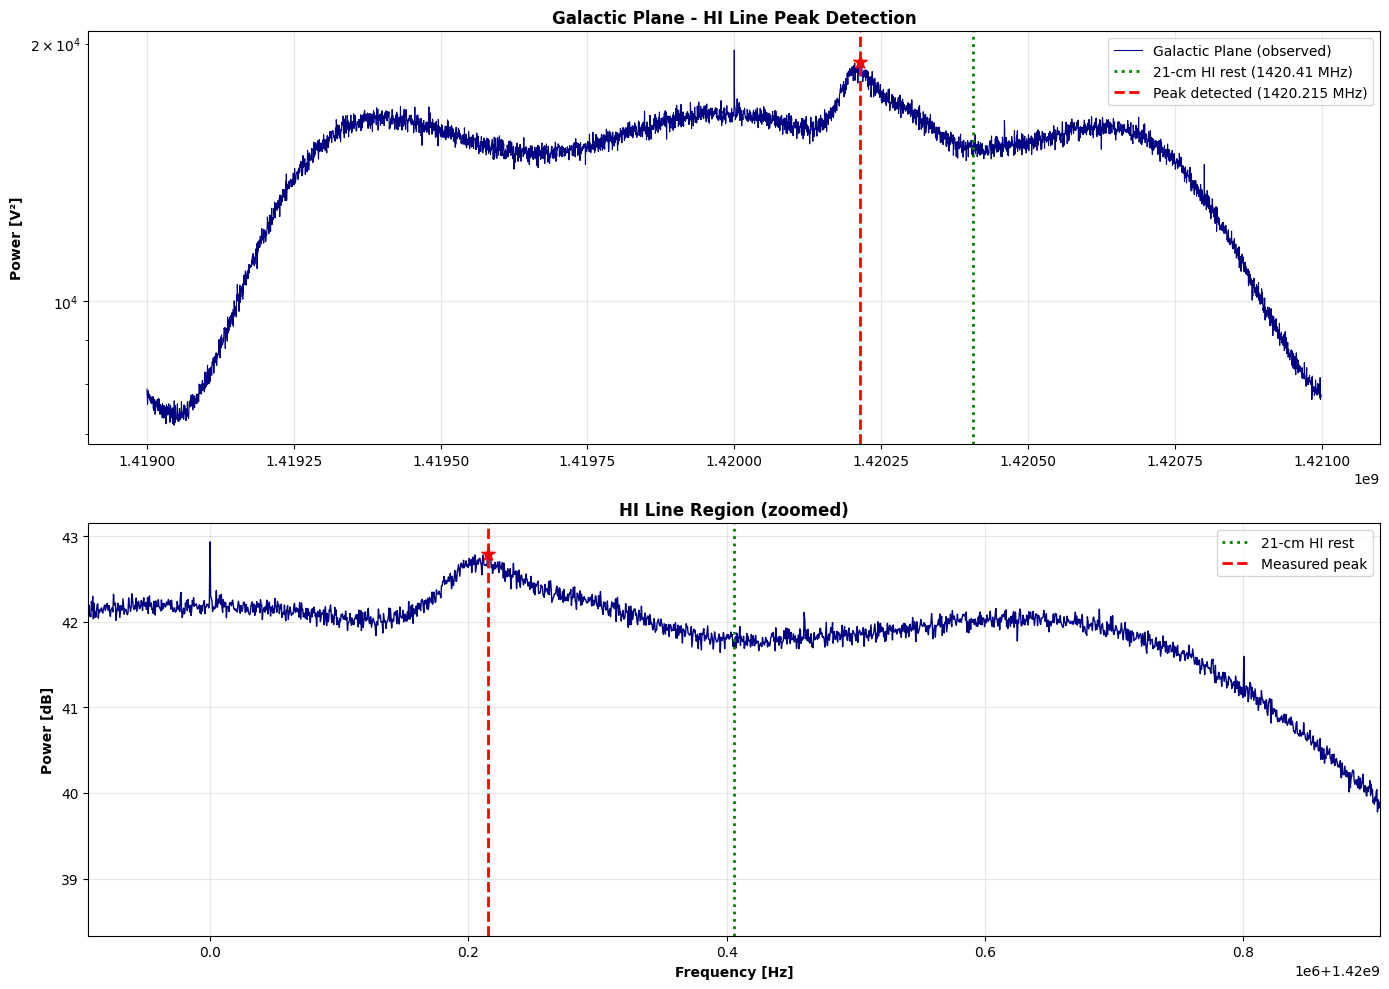

HI LINE VELOCITY MEASUREMENT
Rest frequency (21-cm HI):     1.420406e+09 Hz (1420.405752 MHz)
Observed frequency (peak):     1.420215e+09 Hz (1420.214844 MHz)
Frequency shift:               -1.909e+05 Hz (-190.908 kHz)

MEASURED VELOCITY:             +40.32 km/s

Interpretation:
  → Material receding at 40.32 km/s (redshifted)


In [3]:
# Measure velocity from HI line peak
# Finds the peak frequency in the galactic plane spectrum and calculates velocity

# Load data
fn_gal = "bighorn_galactic_plane.npz"
data_gal = np.load(fn_gal)
samples_gal = data_gal["samples"]

fs_local = 2e6
f_offset = 1420e6
f_HI_rest = 1420.40575177e6  # Rest frequency [Hz]
c = 3e8  # Speed of light [m/s]

# Compute averaged fftshifted power spectrum
num_blocks = samples_gal.shape[0]
N = samples_gal.shape[1]
power_acc = np.zeros(N, dtype=float)

for i in range(num_blocks):
    block = samples_gal[i]
    I_blk = block[:, 0]
    Q_blk = block[:, 1]
    x_blk = I_blk + 1j * Q_blk
    X_blk = np.fft.fft(x_blk)
    X_shift = np.fft.fftshift(X_blk)
    power_shift = (np.abs(X_shift)**2) / N
    power_acc += power_shift

power_avg = power_acc / num_blocks

# Frequency axis (shifted)
freqs = np.fft.fftfreq(N, 1 / fs_local)
freqs_shift = np.fft.fftshift(freqs) + f_offset

# Find peak in power spectrum near the HI line frequency
# Search window around expected HI frequency (±500 kHz)
# BUT exclude DC component by avoiding the center (±50 kHz)
search_window = 500e3  # Hz
dc_tolerance = 50e3  # Hz - exclude DC spike
mask = (freqs_shift >= f_HI_rest - search_window) & (freqs_shift <= f_HI_rest + search_window)
# Also exclude the exact center (DC component)
mask = mask & ((freqs_shift < f_offset - dc_tolerance) | (freqs_shift > f_offset + dc_tolerance))
freqs_window = freqs_shift[mask]
power_window = power_avg[mask]

# Find peak
peak_idx = np.argmax(power_window)
f_observed = freqs_window[peak_idx]
power_peak = power_window[peak_idx]

# Calculate velocity from frequency shift (Doppler formula)
# v = (f_rest - f_obs) / f_rest * c
# Or: v = c * (f_rest - f_obs) / f_rest
velocity_measured = c * (f_HI_rest - f_observed) / f_HI_rest / 1000  # Convert to km/s

# Plot power spectrum with measured peak
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Full spectrum
ax1.plot(freqs_shift, power_avg, color='navy', linewidth=0.8, label='Galactic Plane (observed)')
ax1.axvline(f_HI_rest, color='green', linestyle=':', linewidth=2, label=f'21-cm HI rest ({f_HI_rest/1e6:.2f} MHz)')
ax1.axvline(f_observed, color='red', linestyle='--', linewidth=2, label=f'Peak detected ({f_observed/1e6:.3f} MHz)')
ax1.scatter(f_observed, power_peak, color='red', s=100, zorder=5, marker='*')
ax1.set_yscale('log')
ax1.set_ylabel('Power [V²]', weight='semibold')
ax1.set_title('Galactic Plane - HI Line Peak Detection', weight='semibold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Zoomed in on HI line region
ax2.plot(freqs_shift, 10*np.log10(power_avg + 1e-20), color='navy', linewidth=1)
ax2.axvline(f_HI_rest, color='green', linestyle=':', linewidth=2, label='21-cm HI rest')
ax2.axvline(f_observed, color='red', linestyle='--', linewidth=2, label=f'Measured peak')
ax2.scatter(f_observed, 10*np.log10(power_peak + 1e-20), color='red', s=100, zorder=5, marker='*')
ax2.set_xlabel('Frequency [Hz]', weight='semibold')
ax2.set_ylabel('Power [dB]', weight='semibold')
ax2.set_title('HI Line Region (zoomed)', weight='semibold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

# Set x-axis zoom around HI line
ax2.set_xlim(f_HI_rest - 500e3, f_HI_rest + 500e3)

plt.tight_layout()
os.makedirs('Lab 2/figures', exist_ok=True)
plt.savefig('Lab 2/figures/velocity_measurement_HI_peak.png', dpi=300, bbox_inches='tight')
plt.show()

# Print results
print("="*60)
print("HI LINE VELOCITY MEASUREMENT")
print("="*60)
print(f"Rest frequency (21-cm HI):     {f_HI_rest:.6e} Hz ({f_HI_rest/1e6:.6f} MHz)")
print(f"Observed frequency (peak):     {f_observed:.6e} Hz ({f_observed/1e6:.6f} MHz)")
print(f"Frequency shift:               {f_observed - f_HI_rest:.3e} Hz ({(f_observed - f_HI_rest)/1e3:.3f} kHz)")
print(f"\nMEASURED VELOCITY:             {velocity_measured:+.2f} km/s")
print("\nInterpretation:")
if velocity_measured > 0:
    print(f"  → Material receding at {velocity_measured:.2f} km/s (redshifted)")
else:
    print(f"  → Material approaching at {abs(velocity_measured):.2f} km/s (blueshifted)")
print("="*60)

# Section 6

## 6.2

In [7]:
# Timing

print(data_gal.files)

print("jd_before:", data_gal["jd_before"])
print("utc_before:", data_gal["utc_before"])
print("utc_unix_before:", data_gal["utc_unix_before"])
print("local_before:", data_gal["local_before"])
print("lst_before:", data_gal["lst_before"])


['samples', 'jd_before', 'jd_after', 'utc_before', 'utc_after', 'utc_unix_before', 'utc_unix_after', 'local_before', 'local_after', 'lst_before', 'lst_after', 'coords_altaz', 'coords_nch', 'center_freq', 'sample_rate']
jd_before: 2461090.8462362094
utc_before: Thu Feb 19 08:18:34 2026
utc_unix_before: 1771489114.808501
local_before: Thu Feb 19 00:18:34 2026
lst_before: 2.6474708554650794


In [ ]:
# Y-factor calibration: convert raw power to brightness temperature [K]
# Hot load:  bighorn_wall_blackbody.npz  (~290 K room temp)
# Cold load: bighorn_zenith_v5.npz       (~10 K cold sky at 1.4 GHz)
# On source: bighorn_cyg_x_on.npz
# Off source: bighorn_cyg_x_off_2MHz.npz

# === Parameters ===
T_hot  = 290.0   # K - room temperature blackbody
T_cold = 10.0    # K - approximate sky brightness temp at 1.4 GHz (zenith)
f_HI_rest = 1420.40575177e6  # Hz - 21-cm rest frequency
c = 3e8          # m/s
fs_local = 2e6   # Hz - sampling rate
f_offset = 1420e6  # Hz - LO center frequency

# === Helper: averaged FFT-shifted power spectrum ===
def avg_power_spec(filename):
    d = np.load(filename)
    samps = d["samples"]
    N = samps.shape[1]
    acc = np.zeros(N, dtype=float)
    for blk in samps:
        x = blk[:, 0] + 1j * blk[:, 1]
        Xs = np.fft.fftshift(np.fft.fft(x))
        acc += np.abs(Xs)**2 / N
    Pavg = acc / samps.shape[0]
    freqs = np.fft.fftshift(np.fft.fftfreq(N, 1 / fs_local)) + f_offset
    return freqs, Pavg

# === Load all four spectra ===
f_hot,  P_hot  = avg_power_spec("bighorn_wall_blackbody.npz")
f_cold, P_cold = avg_power_spec("bighorn_zenith_v5.npz")
f_on,   P_on   = avg_power_spec("bighorn_cyg_x_on.npz")
f_off,  P_off  = avg_power_spec("bighorn_cyg_x_off_2MHz.npz")

# === Interpolate onto common frequency axis ===
fmin = max(f_hot.min(), f_cold.min(), f_on.min(), f_off.min())
fmax = min(f_hot.max(), f_cold.max(), f_on.max(), f_off.max())
N_common = min(len(f_hot), len(f_cold), len(f_on), len(f_off))
f_common = np.linspace(fmin, fmax, N_common)

eps = 1e-30
P_hot_i  = np.interp(f_common, f_hot,  P_hot)
P_cold_i = np.interp(f_common, f_cold, P_cold)
P_on_i   = np.interp(f_common, f_on,   P_on)
P_off_i  = np.interp(f_common, f_off,  P_off)

# === Y-factor calibration ===
Y = P_hot_i / (P_cold_i + eps)            # Y(f) = P_hot / P_cold
T_sys = (T_hot - Y * T_cold) / (Y - 1)   # System temperature [K]
T_sys = np.clip(T_sys, 0, 5000)           # Clip unphysical values

# Antenna/brightness temperature of source
T_A = T_sys * (P_on_i - P_off_i) / (P_off_i + eps)

# === Convert frequency to LSR velocity ===
# v = c * (f_rest - f) / f_rest  [positive = receding]
velocity = c * (f_HI_rest - f_common) / f_HI_rest / 1e3  # km/s

# === Plot ===
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(velocity, T_A, color='darkred', linewidth=1)
ax.axvline(0, color='green', linestyle=':', linewidth=1.5, label='v = 0 (HI rest)')
ax.set_xlabel('LSR Velocity [km/s]', weight='semibold')
ax.set_ylabel('Brightness Temperature $T_A$ [K]', weight='semibold')
ax.set_title('Velocity vs Brightness Temperature — Cygnus X (Y-factor calibrated)', weight='semibold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
os.makedirs('Lab 2/figures', exist_ok=True)
plt.savefig('Lab 2/figures/velocity_vs_brightness_temp_cyg_x.png', dpi=300, bbox_inches='tight')
plt.show()

# === Summary ===
print(f"T_hot = {T_hot} K,  T_cold = {T_cold} K")
print(f"Median Y-factor:  {np.median(Y):.3f}")
print(f"Median T_sys:     {np.nanmedian(T_sys):.1f} K")
peak_idx = np.argmax(T_A)
print(f"Peak T_A:         {T_A[peak_idx]:.2f} K  at v = {velocity[peak_idx]:.2f} km/s")
